In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten


In [ ]:
import re
import pandas as pd
from textblob import TextBlob

In [ ]:
dataset_path = "/content/tweets_realtime.csv"  #adding the csv data file 'tweets_realtime'
data = pd.read_csv(dataset_path)

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   text        602 non-null    object 
 1   author_id   602 non-null    float64
 2   created_at  602 non-null    object 
dtypes: float64(1), object(2)
memory usage: 14.2+ KB
None


In [ ]:
#defining a function to clean the data and make it readable for the ML model to interpret
def preprocess_text(text):

    text = text.lower()
    text = re.sub("@[\w]*", "", text)
    text = re.sub("http\S+", "", text)
    text = re.sub("[^a-zA-Z#]", " ", text)
    text = re.sub("rt", "", text)
    text = re.sub("\s+", " ", text)

    return text

#defining a function to assign basic sentiment detected using lexicon method.
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'


In [ ]:
#Pre-processed data needs to resaved in a csv file.
data["preprocessed_text"] = data["text"].apply(preprocess_text)
data['sentiment'] = data['preprocessed_text'].apply(get_sentiment)

data.to_csv("New_realtime_dataset.csv", index=False)

print("Preprocessed dataset saved as 'New_realtime_dataset.csv'")

Preprocessed dataset saved as 'New_realtime_dataset.csv'


In [ ]:
dataset_path_new = "/content/New_realtime_dataset.csv"  #reading the new dataset
new_data = pd.read_csv(dataset_path_new)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.4855 - loss: 1.0505 - val_accuracy: 0.6116 - val_loss: 0.9039
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.5857 - loss: 0.8778 - val_accuracy: 0.7769 - val_loss: 0.6560
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - accuracy: 0.7345 - loss: 0.6009 - val_accuracy: 0.7851 - val_loss: 0.5707
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.8766 - loss: 0.3286 - val_accuracy: 0.7934 - val_loss: 0.6772
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9702 - loss: 0.0987 - val_accuracy: 0.7934 - val_loss: 0.6626
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9970 - loss: 0.0364 - val_accuracy: 0.7851 - val_loss: 0.9428
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9984 - loss: 0.0127 - val_accuracy: 0.7769 - val_loss: 1.0196
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 0.8182 - val_

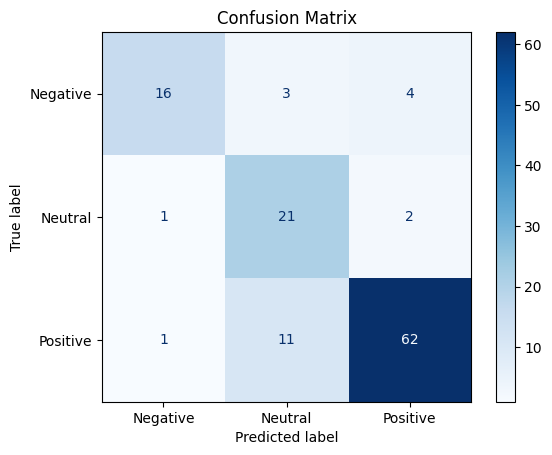

              precision    recall  f1-score   support

    Negative       0.89      0.70      0.78        23
     Neutral       0.60      0.88      0.71        24
    Positive       0.91      0.84      0.87        74

    accuracy                           0.82       121
   macro avg       0.80      0.80      0.79       121
weighted avg       0.85      0.82      0.82       121



In [ ]:
# setting parameters for the model like vocabulary size, max sequence length and embedding dimensions
max_words = 10000
max_len = 100
embedding_dim = 100

def preprocess_data(new_data, max_words, max_len):
    tokenizer = Tokenizer(num_words=max_words)
    tokenizer.fit_on_texts(data['preprocessed_text'])
    sequences = tokenizer.texts_to_sequences(data['preprocessed_text'])
    padded_sequences = pad_sequences(sequences, maxlen=max_len)
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(data['sentiment'])
    return padded_sequences, labels, tokenizer.word_index, label_encoder

X, y, word_index, label_encoder = preprocess_data(data, max_words, max_len)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  CNN-LSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(units=128, return_sequences=False),
    Dense(units=64, activation='relu'),
    Dropout(rate=0.5),
    Dense(units=len(label_encoder.classes_), activation='softmax')  # Adjust output units
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)


y_pred = np.argmax(model.predict(X_test), axis=1) #evaluating the model

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [ ]:
#Visualization of the data !

import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


NameError: name 'history' is not defined

<Figure size 800x600 with 0 Axes>

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


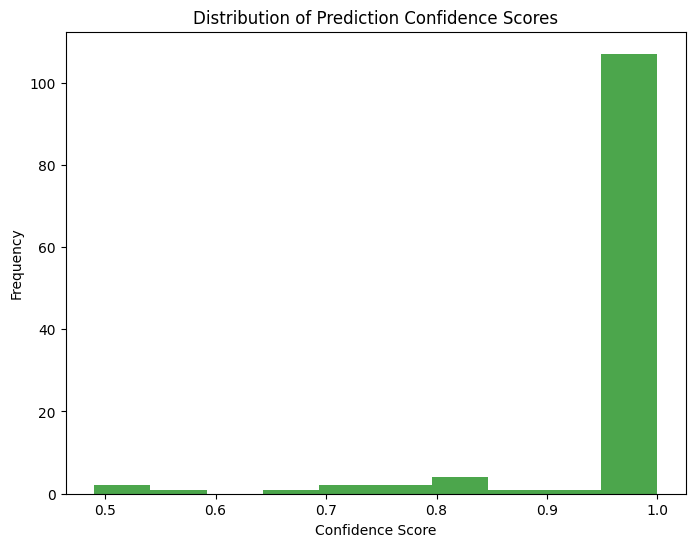

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.max(model.predict(X_test), axis=1), bins=10, color='green', alpha=0.7)
plt.title('Distribution of Prediction Confidence Scores')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.show()

<ipython-input-17-f34abd873f8c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")


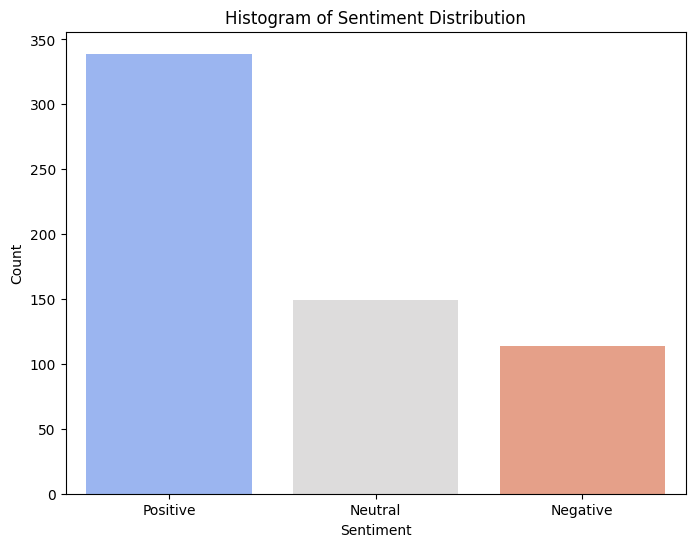

In [ ]:
import seaborn as sns

# Count the sentiment distribution
sentiment_counts = data['sentiment'].value_counts()

# Plot histogram
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")
plt.title('Histogram of Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

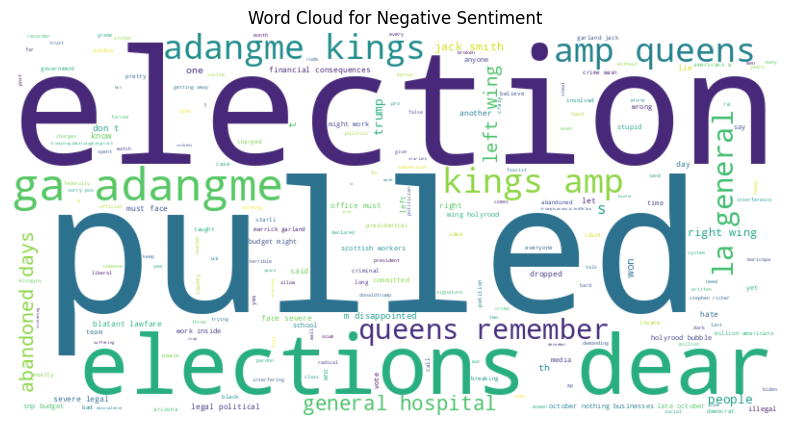

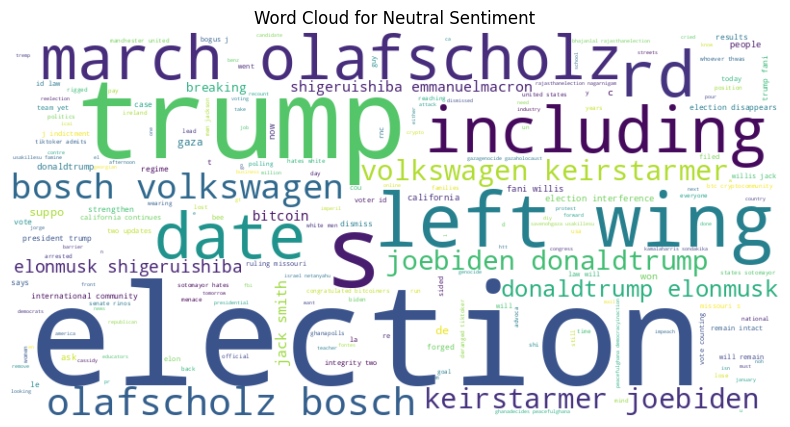

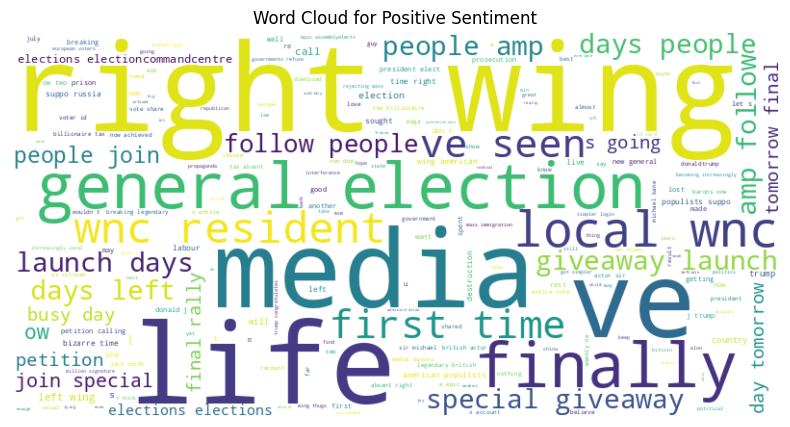

In [ ]:
from wordcloud import WordCloud

# Generate word clouds for each sentiment
for sentiment in label_encoder.classes_:
    sentiment_texts = data[data['sentiment'] == sentiment]['preprocessed_text']
    all_text = ' '.join(sentiment_texts)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {sentiment} Sentiment')
    plt.show()